Differential Imaging Attack (DIA) on RMIST-Net

This script:
  1) Rebuilds RMIST-Net and loads trained weights.
  2) Loads real SAR data, precomputed attack pool D, and RM kernels.
  3) Sets up a differentiable RMA imaging layer in PyTorch.
  4) Reparameterizes the complex gain vector A via latent variables Z.
  5) Optimizes A so that RMIST-Net’s output magnitude matches a desired
     camouflaged template (desired_attacked).
  6) Reports image-space and RMIST-level metrics and visualizes results.

In [1]:
# Imports 
import os
import math
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


- Core RMIST-net

In [2]:
#--------------------- forward kernel and adjoint kernel (imaging kernal)

# Phi and phi_drag
def make_rm_kernels(H, W, R, fc=78.3e9, c=3e8, device="cpu"):
    """
    Build RM forward and adjoint kernels φ_r and φ_r^† on (kx, kz) grid.

    S = RM(α) = IFFT2( FFT2(α) * φ_r )
    α = RM^†(S) = IFFT2( FFT2(S) * φ_r^† )

    H, W : image size (rows=z, cols=x)
    R : range slice (scalar)
    """
    # Image-domain coordinates (relative units)
    x = torch.linspace(-W / 2, W / 2, W, device=device)
    z = torch.linspace(-H / 2, H / 2, H, device=device)
    dx = x[1] - x[0]
    dz = z[1] - z[0]

    # Spatial frequency sampling
    dkx = 2 * math.pi / (W * dx)
    dkz = 2 * math.pi / (H * dz)
    kx = torch.linspace(-W / 2, W / 2, W, device=device) * dkx
    kz = torch.linspace(-H / 2, H / 2, H, device=device) * dkz

    # Meshgrid (Kx, Kz)
    Kx, Kz = torch.meshgrid(kx, kz, indexing="xy")
    K0 = 2 * math.pi * fc / c
    K_sq = Kx**2 + Kz**2
    K_check = 4 * (K0**2) - K_sq
    Ky = torch.sqrt(torch.clamp(K_check, min=0.0))

    # Forward kernel φ_r
    Ky_safe = torch.where(Ky == 0, torch.ones_like(Ky), Ky)
    phi = (1.0 / Ky_safe) * torch.exp(-1j * Ky * R)
    phi = torch.where(Ky == 0, torch.zeros_like(phi), phi)

    # Adjoint kernel φ_r^†
    phi_dag = Ky * torch.exp(1j * Ky * R)

    return phi, phi_dag  # each (W, H) complex


def rm_forward(alpha_ri, phi):
    """
    RM forward: S = RM(α)
    alpha_ri : (B, 2, H, W) [Re, Im]
    phi      : (W, H) complex kernel φ_r
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = alpha_ri.shape
    alpha = torch.complex(alpha_ri[:, 0], alpha_ri[:, 1])  # (B,H,W)
    F_alpha = torch.fft.fft2(alpha)

    # Ensure phi is (H, W)
    if phi.shape[0] == W and phi.shape[1] == H:
        phi_hw = phi.permute(1, 0)
    else:
        phi_hw = phi

    S = F_alpha * phi_hw
    s = torch.fft.ifft2(S)
    return torch.stack([s.real, s.imag], dim=1)


def rm_adjoint(s_ri, phi_dag):
    """
    RM adjoint: α = RM^†(S)
    s_ri     : (B, 2, H, W) [Re, Im]
    phi_dag  : (W, H) complex kernel φ_r^†
    returns  : (B, 2, H, W) [Re, Im]
    """
    B, _, H, W = s_ri.shape
    s = torch.complex(s_ri[:, 0], s_ri[:, 1])
    F_s = torch.fft.fft2(s)

    if phi_dag.shape[0] == W and phi_dag.shape[1] == H:
        phi_dag_hw = phi_dag.permute(1, 0)
    else:
        phi_dag_hw = phi_dag

    A = F_s * phi_dag_hw
    a = torch.fft.ifft2(A)
    return torch.stack([a.real, a.imag], dim=1)


# -----------------------------  RMIST-Net
class RMISTPhase(nn.Module):
    """
    One unrolled ISTA phase:
      v_t       = S - RM(α_t)
      r_t       = α_t + τ_t * RM^†(v_t)
      α_{t+1}   = F_st(r_t, θ_t)
    with complex soft-thresholding F_st.
    """

    def __init__(self, phi, phi_dag):
        super().__init__()
        # Fixed physics kernels
        self.register_buffer("phi", phi)
        self.register_buffer("phi_dag", phi_dag)
        # Trainable scalars τ_t, θ_t
        self.tau = nn.Parameter(torch.tensor(1e-4, dtype=torch.float32))
        self.theta = nn.Parameter(torch.tensor(1e-3, dtype=torch.float32))

    def soft_thresh(self, r):
        """
        Complex soft thresholding:
          α_next = r * max(|r| - θ, 0) / |r|
        r : (B, 2, H, W) [Re, Im]
        """
        real = r[:, 0]
        imag = r[:, 1]
        mag = torch.sqrt(real**2 + imag**2 + 1e-12)
        shr = torch.relu(mag - self.theta)  # max(|r|-θ, 0)
        scale = shr / (mag + 1e-12)
        real2 = real * scale
        imag2 = imag * scale
        return torch.stack([real2, imag2], dim=1)

    def forward(self, S_ri, alpha_ri):
        # Stage 1: residual v_t = S - RM(α_t)
        RM_alpha = rm_forward(alpha_ri, self.phi)
        v = S_ri - RM_alpha

        # Stage 2: gradient step r_t = α_t + τ_t * RM^†(v_t)
        grad = rm_adjoint(v, self.phi_dag)
        r = alpha_ri + self.tau * grad

        # Stage 3: shrinkage α_{t+1} = F_st(r_t, θ_t)
        alpha_next = self.soft_thresh(r)
        return alpha_next


class RMISTNet(nn.Module):
    """
    RMIST-Net: T-phase unrolled RM + ISTA sparse reconstruction network.
    """

    def __init__(self, H, W, R, fc=78.3e9, c=3e8, T=6, device="cpu"):
        super().__init__()
        phi, phi_dag = make_rm_kernels(H, W, R, fc, c, device=device)
        self.phases = nn.ModuleList([RMISTPhase(phi, phi_dag) for _ in range(T)])

    def forward(self, S_ri):
        # Initialization: α_0 = RM^†(S)
        alpha = rm_adjoint(S_ri, self.phases[0].phi_dag)

        # Unroll T ISTA phases
        for phase in self.phases:
            alpha = phase(S_ri, alpha)
        return alpha

- RMA (traditional)

In [3]:
import numpy as np
import torch
import torch.nn.functional as F

def rma_torch(sar_data, params_torch):
    """
    RMA starting from RAW time-domain data.
    sar_data: (Nsamp, M*N) complex (torch.complex64)
    Returns: (img_norm, img_centered) size (nFFTspace, nFFTspace)
    """
    device = sar_data.device

    # -------- RAW -> sarData (M,N) via FFT + range-bin ----------
    Nsamp        = params_torch["Nsamp"]
    M            = params_torch["M"]
    N            = params_torch["N"]
    nFFTtime     = params_torch["nFFTtime"]
    k0_range_bin = params_torch["k0_range_bin"]

    Y_cube = sar_data.reshape(Nsamp, M, N)                  # (Nsamp, M, N)
    Echo   = torch.permute(Y_cube, (2, 1, 0))          # (N, M, Nsamp)
    rawFFT = torch.fft.fft(Echo, n=nFFTtime, dim=2)    # (N, M, nFFTtime)
    sar_slice = rawFFT[:, :, k0_range_bin]             # (N, M)
    sarData   = sar_slice.permute(1, 0)                # (M, N)

    for rr in range(1, M, 2):
        sarData[rr, :] = torch.flip(sarData[rr, :], dims=[0])

    # ------------------- RMA focusing -------------------
    nFFTspace = params_torch["nFFTspace"]
    dx = params_torch["dx"]
    dy = params_torch["dy"]
    F0 = params_torch["F0"]
    z0 = params_torch["z0"]
    c = 3e8
    k = 2 * np.pi * F0 / c

    Mloc, Nloc = sarData.shape
    pad_x = nFFTspace - Nloc
    pad_y = nFFTspace - Mloc
    pad_x_pre = pad_x // 2
    pad_x_post = pad_x - pad_x_pre
    pad_y_pre = pad_y // 2
    pad_y_post = pad_y - pad_y_pre

    sarData_padded = F.pad(
        sarData.unsqueeze(0).unsqueeze(0),
        (pad_x_pre, pad_x_post, pad_y_pre, pad_y_post),
    )[0, 0, :, :]

    wSx = 2 * np.pi / (dx * 1e-3)
    wSy = 2 * np.pi / (dy * 1e-3)
    kX = np.linspace(-wSx / 2, wSx / 2, nFFTspace)
    kY = np.linspace(-wSy / 2, wSy / 2, nFFTspace)
    KX_np, KY_np = np.meshgrid(kX, kY)
    KX_t = torch.tensor(KX_np, dtype=torch.float32, device=device)
    KY_t = torch.tensor(KY_np, dtype=torch.float32, device=device)

    K2 = (2 * k) ** 2 - (KX_t**2 + KY_t**2)
    K2 = torch.clamp(K2, min=0.0)
    Kz = torch.sqrt(K2)

    phase0 = torch.exp(-1j * z0 * Kz)
    ev_mask = (KX_t**2 + KY_t**2) > (2 * k) ** 2
    phase0[ev_mask] = 0.0 + 0.0j

    phase = Kz * phase0
    phase = torch.fft.fftshift(torch.fft.fftshift(phase, dim=0), dim=1)

    sarFFT = torch.fft.fft2(sarData_padded)
    img = torch.fft.ifft2(sarFFT * phase)
    img = torch.fft.fftshift(img, dim=(0, 1))

    mag = torch.abs(img)
    idx = torch.argmax(mag)
    i_max = int(idx // mag.shape[1])
    j_max = int(idx % mag.shape[1])
    center = (nFFTspace - 1) / 2.0
    img = torch.roll(torch.roll(img, int(round(center - i_max)), 0), int(round(center - j_max)), 1)

    img_mag = torch.abs(img)
    #img_norm = img_mag / (torch.sqrt(torch.mean(img_mag**2) + 1e-12))
    return img_mag, img

def S_hat_from_alpha(alpha_complex_torch, Phi_r_dag_torch):
    """
    S_hat = RM(α) in frequency domain:
      F_A   = fft2(α)
      S_tmp = F_A * Phi_r_dag
      S_hat = ifft2(S_tmp) / global_max
    """
    F_A = torch.fft.fft2(alpha_complex_torch)
    S_tmp = F_A * Phi_r_dag_torch
    S_hat = torch.fft.ifft2(S_tmp)
    #S_hat_norm = S_hat / (global_max + 1e-12)
    #return S_hat_norm
    return S_hat

- Victim forward model (RMA only or RMA + RMIST-Net) and generate target image

In [ ]:
def victim_forward(
    raw_vec: torch.Tensor,                 # (Nsamp, M*N) complex
    params_torch: dict,
    mode: str = "rma+rmist",                # "rma" or "rma+rmist"
    model: torch.nn.Module | None = None,
    Phi_r_dag: torch.Tensor | None = None,
    do_rms_norm: bool = False,
):
    """
    raw_vec: (Nsamp, M*N) complex torch tensor

    returns:
      mode="rma"       -> (rma_img_mag, rma_img_cplx)
      mode="rma+rmist" -> (rma_img_mag, rma_img_cplx, alpha_mag)

    Uses your existing rma_torch() which expects (Nsamp, M*N) complex.
    """

    # ---- RMA-only (your rma_torch already does reshape to (Nsamp,M,N) internally) ----
    rma_img_mag, rma_img_cplx = rma_torch(raw_vec, params_torch)

    if mode == "rma":
        return rma_img_mag, rma_img_cplx

    # ---- RMA + RMIST ----
    if model is None or Phi_r_dag is None:
        raise ValueError("mode='rma+rmist' requires model and Phi_r_dag.")

    H, W = Phi_r_dag.shape

    # center-crop RMA complex to (H,W) if needed
    if rma_img_cplx.shape != (H, W):
        ph = (rma_img_cplx.shape[0] - H) // 2
        pw = (rma_img_cplx.shape[1] - W) // 2
        img_crop = rma_img_cplx[ph:ph+H, pw:pw+W]
    else:
        img_crop = rma_img_cplx

    # S_hat: complex (H,W)
    S_hat = S_hat_from_alpha(img_crop, Phi_r_dag)

    # (1,2,H,W) float tensor for RMIST-Net
    S_hat_t = torch.stack([S_hat.real, S_hat.imag], dim=0).unsqueeze(0)
    S_hat_t = S_hat_t.to(torch.float32).to(raw_vec.device)
 
    alpha_pred = model(S_hat_t)  # (1,2,H,W)

    alpha_mag = torch.sqrt(alpha_pred[:, 0]**2 + alpha_pred[:, 1]**2 + 1e-12).unsqueeze(1)  # (1,1,H,W)
    if do_rms_norm:
        alpha_mag = alpha_mag / torch.sqrt(torch.mean(alpha_mag**2) + 1e-12)

    return rma_img_mag, rma_img_cplx, alpha_mag
'''
def random_noise_target(H: int, W: int, device, seed: int = 0):
    g = torch.Generator(device=device).manual_seed(seed)
    x = torch.abs(torch.randn(H, W, device=device, dtype=torch.float32, generator=g))
    return x.unsqueeze(0).unsqueeze(0)


# -------- Target image from a complex target
def generate_target_img(desired_attacked_np):
    """
    Build target magnitude image from desired_attacked.
    """
    mag = np.abs(desired_attacked_np)
    t = torch.tensor(mag, dtype=torch.float32, device=device)
    return t.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

def maxabs_norm(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return x / (x.abs().amax() + eps
'''

- Load the data and model

In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from scipy.io import loadmat

# ============================================================
# 0) Paths + load data
# ============================================================
dir_path = os.getcwd()

rawSAR = loadmat(os.path.join(dir_path, "data", "rawSAR.mat"))["adcDataCube"]      # (Nsamp,M,N)
D_np   = loadmat(os.path.join(dir_path, "data", "D.mat"))["D"]                    # (Nsamp,Np)
Phi_np = loadmat(os.path.join(dir_path, "data", "Phi_r_dag.mat"))["Phi_r_dag"]    # (H,W)

D_t = torch.tensor(D_np, dtype=torch.complex64, device=device)                    # (Nsamp,Np)
Phi_r_dag = torch.tensor(Phi_np.astype(np.complex64),
                         dtype=torch.complex64, device=device)                    # (H,W)


# ============================================================
# 1) Preprocess rawSAR -> X_v (Nsamp,Np)
# ============================================================
Nsamp, M, N = rawSAR.shape
Np = M * N

X_v_np = rawSAR.reshape(Nsamp, Np).astype(np.complex64)                           # (Nsamp,Np)
X_v_t  = torch.tensor(X_v_np, dtype=torch.complex64, device=device)               # (Nsamp,Np)

# ============================================================
# 2) SAR params (for rma_torch)
# ============================================================
c0 = 3e8
F0 = 77e9
FS = 5_000_000.0
K0 = 70.295e12
tI = 4.5225e-10

nFFTtime  = Nsamp
nFFTspace = 512
ID_select = 6
k0_range_bin = ID_select - 1
z0 = c0 / 2.0 * (ID_select / (K0 * (1.0 / FS) * nFFTtime) - tI)

params_torch = {
    "Nsamp": Nsamp, "M": M, "N": N,
    "nFFTtime": nFFTtime,
    "k0_range_bin": k0_range_bin,
    "nFFTspace": nFFTspace,
    "dx": 1.0, "dy": 1.0,
    "F0": F0, "z0": z0,
}

# ============================================================
# 3) Load RMIST-Net
# ============================================================
H, W = 512, 512
R_mat = 0.185
T_phases = 9

model = RMISTNet(H, W, R=R_mat, device=device, T=T_phases).to(device)
state_dict = torch.load(os.path.join(dir_path, "trained_model", "RMISTNet_weights.pth"),
                        map_location=device)
model.load_state_dict(state_dict)
model.eval()

C:\Users\Lhamo\AppData\Local\Temp\ipykernel_24612\1605098786.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(os.path.join(dir_path, "trained_mod

RMISTNet(
  (phases): ModuleList(
    (0-8): 9 x RMISTPhase()
  )
)

- Differential Imaging Attack on RMA+RMIST

In [ ]:
# ============================================================
# 4) Target + clean (normalize with maxabs)
# ============================================================
#target_img = generate_target_img(desired_attacked)   # (1,1,H,W), float
#torch.manual_seed(0)
#torch.cuda.manual_seed_all(0)   # if using CUDA

#target_img = random_noise_target(H, W, device, seed=123)
#target_img = random_noise_target(H, W, device)
#target_img = maxabs_norm(target_img)

# ---- Generate clean image 
with torch.no_grad():
    _, _, clean_img = victim_forward(
        X_v_t, params_torch,
        mode="rma+rmist",
        model=model,
        Phi_r_dag=Phi_r_dag,
        do_rms_norm=False
    )                                                # (1,1,H,W)
#clean_img = maxabs_norm(clean_img)
global_scale = clean_img.abs().amax() + 1e-12  # scalar
clean_img  = clean_img  / global_scale

# ---- Generate traget image 
seed = 42
rng = np.random.default_rng(seed)

X_v_shuf_np = X_v_np.copy()
for t in range(Nsamp):
    X_v_shuf_np[t, :] = X_v_shuf_np[t, rng.permutation(Np)]  # shuffle across aperture samples

X_v_shuf_t = torch.tensor(X_v_shuf_np, dtype=torch.complex64, device=device)

# --- 2) generate target image using RMIST victim_forward ---
with torch.no_grad():
    _, _, target_img = victim_forward(
        X_v_shuf_t, params_torch,
        mode="rma+rmist",
        model=model,
        Phi_r_dag=Phi_r_dag,
        do_rms_norm=False
    )  # (1,1,H,W)


target_img = target_img / global_scale


# ============================================================
# 5) DIA optimization (hard projection |A|<=Amax)
# ============================================================
Amax           = 2.0
lambda_L2      = 1e-5
num_iters      = 500
lr_high        = 1e-1 #---------------
lr_low         = 1e-2
lr_switch_iter = 10_000_000  # effectively never

A_re = torch.nn.Parameter(1e-3 * torch.randn(Np, device=device))
A_im = torch.nn.Parameter(1e-3 * torch.randn(Np, device=device))
optimizer = torch.optim.Adam([A_re, A_im], lr=lr_high)

print(f"\n[Attack] Starting DIA over A, Np={Np}, lr={lr_high:.3e}\n")

for it in range(1, num_iters + 1):

    if it == lr_switch_iter + 1:
        for g in optimizer.param_groups:
            g["lr"] = lr_low
        print(f"[LR] switched Adam lr from {lr_high:.3e} to {lr_low:.3e}\n")

    optimizer.zero_grad()

    # current A (Np,)
    A_raw = torch.complex(A_re, A_im)                          # (Np,)

    # inject
    delta = D_t * A_raw.unsqueeze(0)                           # (Nsamp,Np)
    X_adv = X_v_t + delta                                      # (Nsamp,Np)

    # victim pipeline
    _, _, adv_img = victim_forward(
        X_adv, params_torch,
        mode="rma+rmist",
        model=model,
        Phi_r_dag=Phi_r_dag,
        do_rms_norm=False
    )                                                          # (1,1,H,W)

    # normalize (maxabs)
    #adv_img = maxabs_norm(adv_img)
    adv_img = adv_img/global_scale

    # losses
    loss_img = F.mse_loss(adv_img, target_img)
    loss_reg = lambda_L2 * torch.mean(torch.abs(A_raw)**2)
    loss     = loss_img + loss_reg

    loss.backward()
    optimizer.step()

    # hard projection on parameters: enforce |A|<=Amax
    with torch.no_grad():
        A_post = torch.complex(A_re, A_im)
        mag_post = torch.abs(A_post)
        scale_post = torch.clamp(Amax / (mag_post + 1e-12), max=1.0)
        A_proj = A_post * scale_post
        A_re.copy_(A_proj.real)
        A_im.copy_(A_proj.imag)

    # logging
    if it % 50 == 0 or it == 1 or it == num_iters:
        with torch.no_grad():
            A_log  = torch.complex(A_re, A_im)
            meanA  = torch.mean(torch.abs(A_log)).item()
            maxA   = torch.max(torch.abs(A_log)).item()

            mse_AT = F.mse_loss(adv_img, target_img).item()
            mse_CA = F.mse_loss(adv_img, clean_img).item()

            PaPr = (torch.linalg.norm(delta) /
                    (torch.linalg.norm(X_v_t) + 1e-12)).pow(2).item()

            g_re = 0.0 if A_re.grad is None else torch.max(torch.abs(A_re.grad)).item()
            g_im = 0.0 if A_im.grad is None else torch.max(torch.abs(A_im.grad)).item()
            Gnow = max(g_re, g_im)
            lr_now = optimizer.param_groups[0]["lr"]

        print(
            f"Iter {it:04d}/{num_iters:04d} | "
            f"Loss={loss.item():.4e}, G={Gnow:.3e},| "
            f"MSE(A,T)={mse_AT:.4e}, MSE(C,A)={mse_CA:.4e} | "
            f"E|A|={meanA:.4e}, max|A|={maxA:.4e}, Pa/Pr={PaPr:.4e}"
        )

print("Attack optimization finished.")


[Attack] Starting DIA over A, Np=40000, lr=1.000e-01

Iter 0001/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=2.9655e+22 | E|A|=1.2657e-03, max|A|=1.0112e-01, Pa/Pr=1.9862e-06
Iter 0050/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=3.4384e+22 | E|A|=1.2657e-03, max|A|=1.0112e-01, Pa/Pr=2.9791e-06
Iter 0100/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=3.4384e+22 | E|A|=1.2657e-03, max|A|=1.0112e-01, Pa/Pr=2.9791e-06
Iter 0150/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=3.4384e+22 | E|A|=1.2657e-03, max|A|=1.0112e-01, Pa/Pr=2.9791e-06
Iter 0200/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=3.4384e+22 | E|A|=1.2657e-03, max|A|=1.0112e-01, Pa/Pr=2.9791e-06
Iter 0250/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=3.4384e+22 | E|A|=1.2657e-03, max|A|=1.0112e-01, Pa/Pr=2.9791e-06
Iter 0300/0500 | Loss=5.2013e+28, G=6.900e+25,| MSE(A,T)=5.2013e+28, MSE(C,A)=3.4

- Evaluations

In [ ]:
with torch.no_grad():
    # Attacked pass (using X_adv_final from the attack loop)
    A_final = torch.complex(A_re, A_im)              # (Np,)
    delta   = D_t * A_final.unsqueeze(0)             # (Nsamp, Np)
    X_adv_final = X_v_t + delta           
    _, _, adv_img = victim_forward(
        X_adv_final, params_torch,
        mode="rma+rmist",
        model=model,
        Phi_r_dag=Phi_r_dag,
        do_rms_norm=False
    )  # (1,1,H,W)
adv_img = adv_img/global_scale
adv_img = adv_img[0,0].detach().cpu().numpy()
clean_img = clean_img[0,0].detach().cpu().numpy()
target_img = target_img[0,0].detach().cpu().numpy()

print(f"adv_img    min/max: {adv_img.min():.6e} / {adv_img.max():.6e}")
print(f"clean_img  min/max: {clean_img.min():.6e} / {clean_img.max():.6e}")
print(f"target_img min/max: {target_img.min():.6e} / {target_img.max():.6e}")


adv_img    min/max: 9.183673e+08 / 3.571063e+15
clean_img  min/max: 4.120140e+09 / 3.571628e+15
target_img min/max: 7.286341e+10 / 5.716428e+14


C:\Users\Lhamo\AppData\Local\Temp\ipykernel_24612\408722536.py:14: RuntimeWarning: overflow encountered in scalar multiply
  den = np.sqrt(np.sum(adv_img**2) * np.sum(target_img**2)) + 1e-12
c:\Users\Lhamo\anaconda3\envs\rmist-gpu\lib\site-packages\skimage\metrics\_structural_similarity.py:268: RuntimeWarning: overflow encountered in multiply
  D = B1 * B2
c:\Users\Lhamo\anaconda3\envs\rmist-gpu\lib\site-packages\skimage\metrics\_structural_similarity.py:269: RuntimeWarning: overflow encountered in multiply
  S = (A1 * A2) / D
c:\Users\Lhamo\anaconda3\envs\rmist-gpu\lib\site-packages\skimage\metrics\_structural_similarity.py:269: RuntimeWarning: invalid value encountered in divide
  S = (A1 * A2) / D



--- RMIST image-level attack metrics (NO RMS) ---
MSE(A,T): 5.2013e+28, (matlab equivalent: 1.4309e+00)
MSE(C,A): 3.4384e+22
NCC     : 0.0000
SSIM    : nan
PSNR    : 7.98 dB


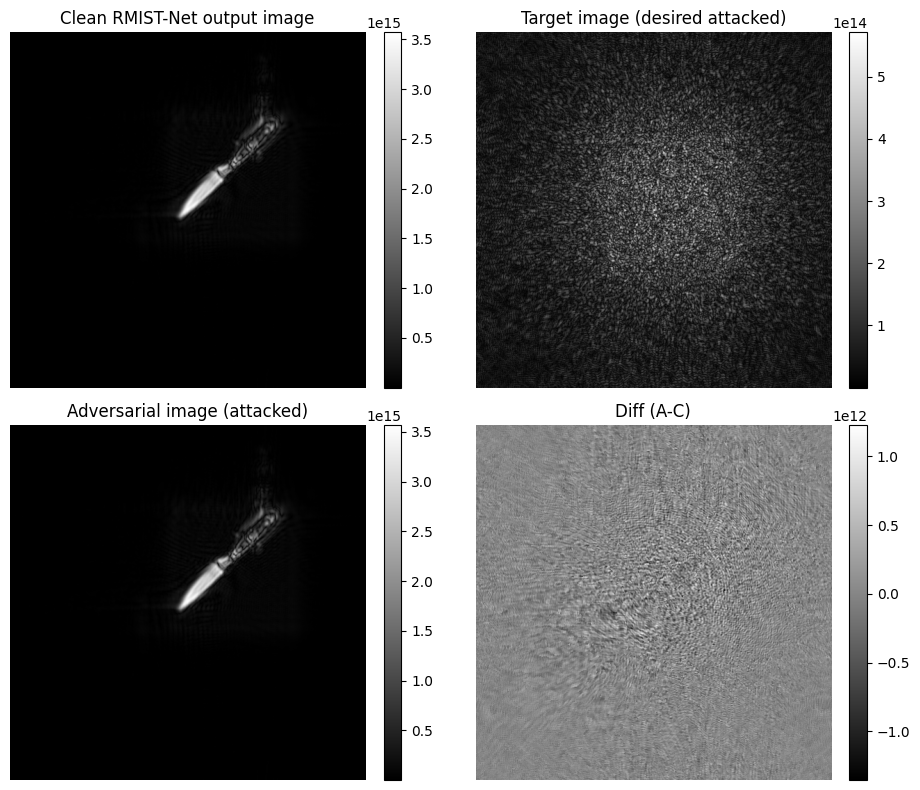

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ------------------------------------------------------------
# Metrics (NO RMS normalization)
# ------------------------------------------------------------
mse_AT = np.mean((adv_img - target_img) ** 2)     # MSE(Adv, Target)
mse_val2 = np.mean((adv_img/np.sqrt(np.mean(np.square(adv_img))) - target_img/np.sqrt(np.mean(np.square(target_img)))) ** 2)
mse_CA = np.mean((adv_img - clean_img) ** 2)      # MSE(Adv, Clean)

num = np.sum(adv_img * target_img)
den = np.sqrt(np.sum(adv_img**2) * np.sum(target_img**2)) + 1e-12
ncc_val = num / den

data_range = float(target_img.max() - target_img.min() + 1e-12)
ssim_val = ssim(adv_img, target_img, data_range=data_range)
psnr_val = psnr(target_img, adv_img, data_range=data_range)

print("\n--- RMIST image-level attack metrics (NO RMS) ---")
print(f"MSE(A,T): {mse_AT:.4e}, (matlab equivalent: {mse_val2:.4e})")
print(f"MSE(C,A): {mse_CA:.4e}")
print(f"NCC     : {ncc_val:.4f}")
print(f"SSIM    : {ssim_val:.4f}")
print(f"PSNR    : {psnr_val:.2f} dB")

# ------------------------------------------------------------
# Plots: clean / target / adv / diff (compact 2x2)
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

ax1 = plt.subplot(2,2,1)
im1 = ax1.imshow(clean_img, cmap="gray")
ax1.set_title("Clean RMIST-Net output image"); ax1.axis("off")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(2,2,2)
im2 = ax2.imshow(target_img, cmap="gray")
ax2.set_title("Target image (desired attacked)"); ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = plt.subplot(2,2,3)
im3 = ax3.imshow(adv_img, cmap="gray")
ax3.set_title("Adversarial image (attacked)"); ax3.axis("off")
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = plt.subplot(2,2,4)
im4 = ax4.imshow(adv_img - clean_img, cmap="gray")
ax4.set_title("Diff (A-C)"); ax4.axis("off")
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

- Extra 